In [3]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import datetime
import io
import datetime
import matplotlib.lines as mlines
from fredapi import Fred
import statsmodels.formula.api as smf
import datetime

Step 1.
Using interest rate differential to compute a trading strategy

In [4]:
currency = "EURUSD=X"
exrate = yf.download(currency)[["Adj Close"]].copy()
exrate
exrate = exrate.set_index(exrate.index.date)

[*********************100%***********************]  1 of 1 completed


In [5]:
interest =pd.read_csv("/Users/Dhriti/Desktop/hw2_data.csv", parse_dates = True, index_col = 0)
interest

,I_US,I_EU,Inf_US,Inf_EU,Euro
2003-12-01,1.11,2.1590,0.019284,0.021933,1.196501
2004-01-01,1.10,2.1463,0.020352,0.020207,1.258194
2004-02-01,1.06,2.0895,0.020263,0.018343,1.246805
2004-03-01,1.05,2.0706,0.016885,0.016654,1.244803
2004-04-01,1.05,2.0288,0.017401,0.017175,1.236507
...,...,...,...,...,...
2022-08-01,2.50,0.0366,0.084821,0.088662,1.020825
2022-09-01,2.76,0.3947,0.082492,0.091406,1.003905
2022-10-01,3.21,1.0109,0.082224,0.099272,0.982956
2022-11-01,3.85,1.4277,0.077631,0.106206,0.988631


In [6]:
# Implementing min max scaling
def scale(x):
    return (x-x.min())/(x.max()-x.min())

# Apply Scaling
interest["ir_diff"] = scale(interest["I_US"]) - scale(interest["I_EU"])
interest.dropna(inplace= True)

<AxesSubplot:title={'center':'Interest Rate Differential With Scaling'}>

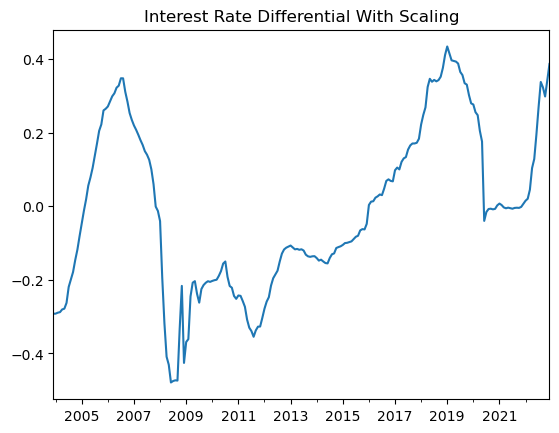

In [7]:
plt.title("Interest Rate Differential With Scaling")
interest["ir_diff"].plot()

In [8]:
interest["ir_diff"]

2003-12-01   -0.292402
2004-01-01   -0.292024
2004-02-01   -0.289458
2004-03-01   -0.287991
2004-04-01   -0.280651
                ...   
2022-08-01    0.337677
2022-09-01    0.322946
2022-10-01    0.298081
2022-11-01    0.343414
2022-12-01    0.386580
Name: ir_diff, Length: 229, dtype: float64

Step 2. 
Fitting a Kalman Filter to the differential series I constructed using interest rate differential.

In [11]:
k = 0.05
w = 5
z = 0

interest["Filter"] = interest.ir_diff.ewm(alpha = k, adjust = False).mean()

# Computed the filter error
interest["Filter Error"] = interest.ir_diff - interest["Filter"]

# computed the rolling standard deviation
interest["std"] = interest["Filter Error"].rolling(w).std()

interest["Upper"] = interest["Filter"] + z*interest["std"]
interest["Lower"] = interest["Filter"] - z*interest["std"]

interest["test"] = np.where(interest["Filter Error"].abs()>z*interest["std"], -1, 0)*np.sign(interest["Filter Error"])

For each period in the history of the series I generated signals by creating boundaries of inaction around my filter using standard deviations computed over some window (w) and some number of standard deviations (z).

In [12]:

drange = pd.date_range(start =interest.index[0], end = "01/01/2023")
daily  = pd.DataFrame(index = drange)


daily["test"] = interest["test"]

daily["Upper"] = interest["Upper"]
daily["Lower"] = interest["Lower"]
daily["Filter"] = interest["Filter"]
daily["ir_diff"] = interest["ir_diff"]

# Fill NA values with the last available value
daily["Upper"] = daily["Upper"].ffill()
daily["Lower"] = daily["Lower"].ffill()
daily["Filter"] = daily["Filter"].ffill()
daily["ir_diff"] = daily["ir_diff"].ffill()

daily = daily.fillna(0)

In [13]:
# Below is the holding period I use for the CI strategy
i = 171
daily.loc[:, str(i)+"_signal"] = 0
for j in daily.index:
    if daily.loc[j, "test"] != 0:
        daily.loc[j:j+datetime.timedelta(i), str(i)+"_signal"] = daily.loc[j, "test"]
        

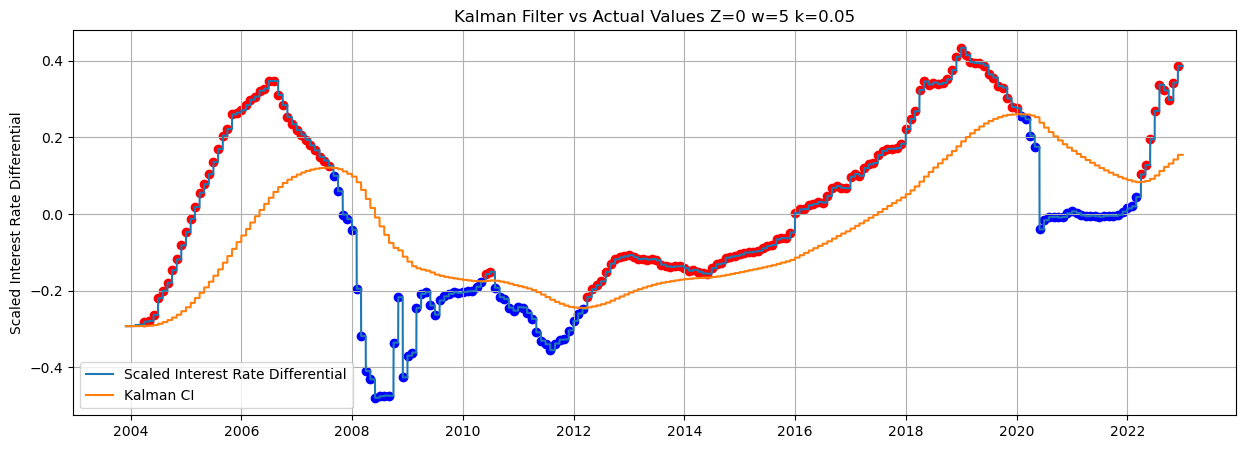

In [14]:
data2 = daily.dropna()
fig, ax = plt.subplots(figsize = (15, 5))
ax.set_title("Kalman Filter vs Actual Values " + "Z="+str(z) + " w=" + str(w)+ " k=" + str(k))

ax.set_ylabel("Scaled Interest Rate Differential")

# Plot the actual series and the filter
ax.plot(data2["ir_diff"])
ax.plot(data2["Filter"])

ax.scatter(data2[data2.test == 1].index, data2[data2.test == 1]["ir_diff"], color = "blue")
ax.scatter(data2[data2.test == -1].index, data2[data2.test == -1]["ir_diff"], color = "red")
ax.legend(["Scaled Interest Rate Differential", "Kalman CI"])

ax.grid()

The Kalman filter helps in deciding our trading strategy. The kalman filter with respect the actual value helps us decide to short or long our position. 


I formulate a trading strategy based on the signals created . I generate long or short positions according to the link between exchange rates and economic fundamentals.

In [15]:
# below we add the euro data to the daily df
drange = pd.date_range(start =interest.index[0], end = "12/01/2022")
exdf = pd.DataFrame(index = drange)

exdf["EURUSD"] = exrate
exdf["EURUSD"] = exdf["EURUSD"].ffill()

daily["EURUSD"] = exdf["EURUSD"]
daily["Returns"] = np.log(daily["EURUSD"]).diff()

In [16]:
i = 171
daily[str(i)+"_returns"] = np.exp((daily[str(i)+"_signal"].shift()*daily.Returns).cumsum())-1
s = 171
daily[str(s)+"_success"] = ((daily[daily.test!= 0][str(s)+"_returns"].diff()>0)*1).shift(-1)

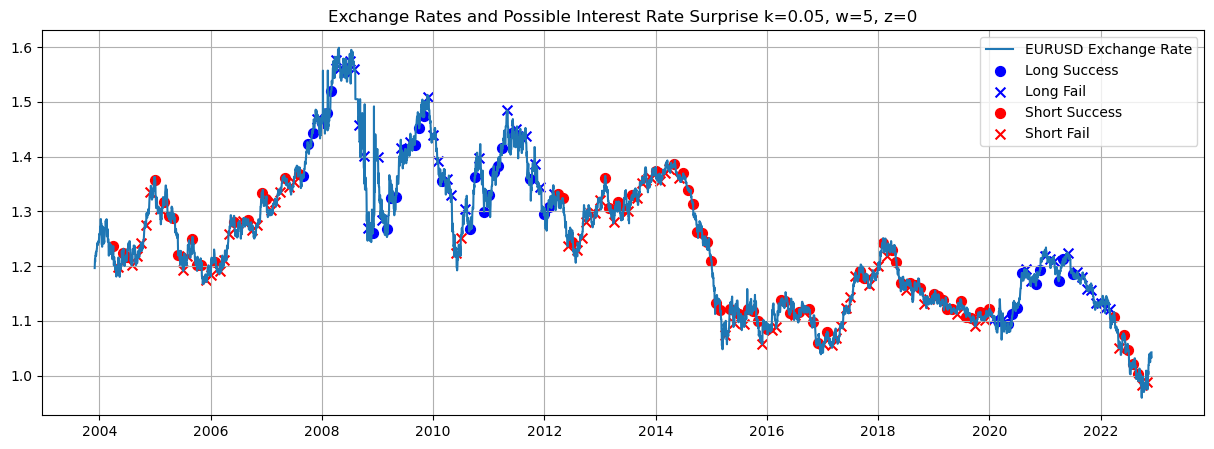

In [17]:
plt.figure(figsize = (15, 5))

plt.title("Exchange Rates and Possible Interest Rate Surprise"+ " k=" + str(k)+", w="+str(w)+", z="+str(z))

plt.plot(daily["EURUSD"])

longsuccess = daily[(daily[str(s)+"_success"] == 1) & (daily["test"] == 1)]
longfail = daily[(daily[str(s)+"_success"] == 0) & (daily["test"] == 1)] 
shortsuccess = daily[(daily[str(s)+"_success"] == 1) & (daily["test"] == -1)]
shortfail = daily[(daily[str(s)+"_success"] == 0) & (daily["test"] == -1)]

plt.scatter(longsuccess.index, longsuccess["EURUSD"], color = 'blue', s = 50)
plt.scatter(longfail.index, longfail["EURUSD"], color = 'blue', s = 50, marker = "x")

plt.scatter(shortsuccess.index, shortsuccess["EURUSD"], color = 'red', s = 50)
plt.scatter(shortfail.index, shortfail["EURUSD"], color = 'red', s = 50, marker = "x")

plt.legend(["EURUSD Exchange Rate", "Long Success", "Long Fail", "Short Success", "Short Fail"])

plt.grid()

The graph shows how our strategy performed based on the EURUSD exchange rate. Long success is when our long position was a success and short success is when our short position was a success. Similarly, the short fail and long fail indicates that our strategy was not successful. 

Visualizing the equity curve of my strategy.

In [18]:
mret = str(i)+"_returns"

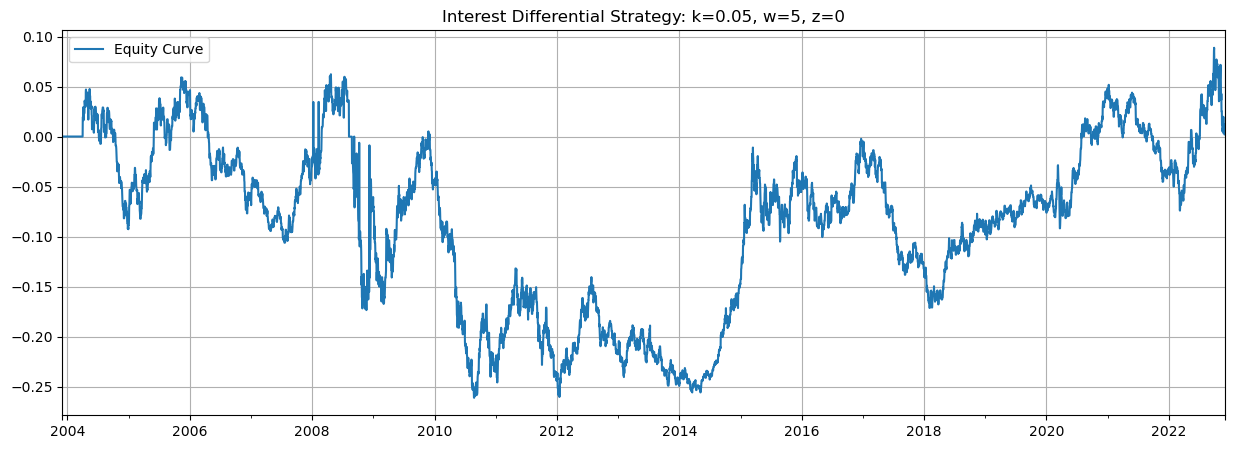

In [19]:
plt.figure(figsize = (15, 5))
d2 = daily[daily.index.year >= 2020]
(daily["171_returns"].dropna()).plot()

plt.title("Interest Differential Strategy:"+ " k=" + str(k)+", w="+str(w)+", z="+str(z))
plt.legend(["Equity Curve", "Long Success", "Long Fail", "Short Success", "Short Fail"])

plt.grid()

Equity curve shows how our strategy performed using k=0.05, w=5 and z = 0 is performing over a given time frame. In our graph from around 2011 our strategy is not performing well, but it picks up from aroud 2015. 

In [21]:
mret 

'171_returns'

In [23]:
start = daily[["EURUSD", mret, "171_signal"]][123:].index[0]

In [24]:
df = daily[daily.test != 0][["171_signal", "EURUSD"]].copy()
df['D'] = df["171_signal"]

In [25]:
df = df[:-2].copy()

In [28]:
df = df[:-2].copy()
df['s_current'] = daily[daily.index.isin(df.index)]["EURUSD"].values
df['s_future'] = daily[daily.index.isin(df.index+datetime.timedelta(41))]["EURUSD"].values


# Get the realized exchange rate
df['R'] = np.where(df['s_future'] >= df['s_current'], 1, -1)

In [30]:
## Sample Covariance
df['W'] = (df['D']-np.mean(df['D']))*(df['R']-np.mean(df['R']))
T_B = np.mean(df['W'])

In [31]:
T_B

-0.036016904160207336

In [32]:
## Newey-West LRV estimator
dy = df['W'] - np.mean(df['W'])
gamma_0 = sum((dy)**2)/len(df)
gamma_1 = np.mean((dy*dy.shift(-1))[:len(df)-1])
LRV = gamma_0 + 2*(1-1/2)*gamma_1

In [33]:
## Test-statistic
from scipy.stats import norm

statistic = T_B/np.sqrt(LRV/df.shape[0])
print('Test statistic : ', statistic, ', 5 % critical value : ', round(norm.ppf(0.95),2))

Test statistic :  -0.4967683770332748 , 5 % critical value :  1.64


We fail to reject the null. Hence, this suggests that our directional forecasts has not successfully been captured the realized appreciation or depreciation of exchange rates.

### Weighted Binomial Test (Weighted Directional Test)

In [34]:
# Weighted Mean
df['W_2'] = df['D']*(df['s_future']-df['s_current'])
T_WB = np.mean(df['W_2'])

In [35]:
T_WB

-0.0017995773921913815

In [36]:
## Newey-West LRV estimator
dy_2 = df['W_2'] - np.mean(df['W_2'])
gamma_0 = sum((dy_2)**2)/len(df)
gamma_1 = np.mean((dy_2*dy_2.shift(-1))[:len(df)-1])
LRV_2 = gamma_0 + 2*(1-1/2)*gamma_1

In [39]:
## Test-statistic
statistic_2 = T_WB/np.sqrt(LRV_2/len(df))
print('Test statistic : ', statistic_2, ', 5 % critical value : ', round(norm.ppf(0.95),2))

Test statistic :  -0.5730694662662787 , 5 % critical value :  1.64


We fail to reject the null. Hence, this suggests that our directional forecasts has not successfully been captured the realized appreciation or depreciation of exchange rates.